In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

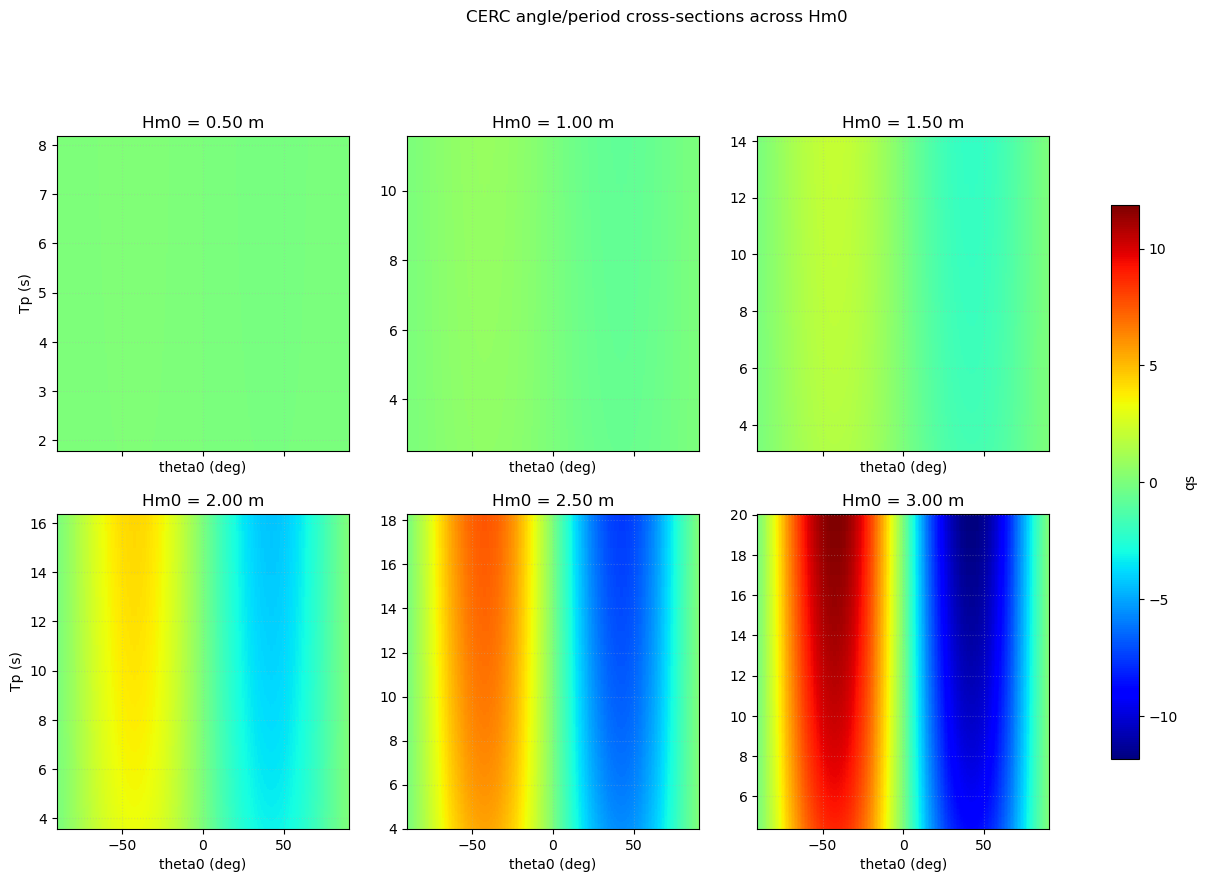

In [2]:
hm0_min, hm0_max = 0.5, 3.0
s0_min, s0_max = 0.005, 0.1
ang_min, ang_max = -90.0, 90.0

n_hm0_slices = 6  # n cross sections plotted
n_ang = 200
n_s0 = 200

k = 1.0  

hm0_slices = np.linspace(hm0_min, hm0_max, n_hm0_slices)
ang_values = np.linspace(ang_min, ang_max, n_ang)
s0_values = np.linspace(s0_min, s0_max, n_s0)

ang_grid, s0_grid = np.meshgrid(ang_values, s0_values, indexing="xy")
angle_term = np.radians(ang_grid)

qs_slices = []
tp_slices = []

for hm0 in hm0_slices:
    tp_da = np.sqrt(hm0 / (1.56 * s0_grid))   
    hs_da = hm0                                

    cos_term = np.cos(angle_term)
    sin_term = np.sin(angle_term)
    qs = -k * (tp_da ** 0.2) * (hs_da ** 2.4) * (cos_term ** 1.2) * sin_term

    qs_slices.append(qs)
    tp_slices.append(tp_da)

vmax = max(np.abs(qs).max() for qs in qs_slices)
norm = Normalize(-vmax, vmax)
cmap = plt.cm.jet

fig, axs = plt.subplots(2, 3, figsize=(16, 9), sharex=True)

for i, (ax, hm0, tp_da, qs) in enumerate(zip(axs.flat, hm0_slices, tp_slices, qs_slices)):
    pcm = ax.pcolormesh(ang_grid, tp_da, qs, cmap=cmap, norm=norm, shading="auto")
    ax.set_title(f"Hm0 = {hm0:.2f} m")
    ax.set_xlabel("theta0 (deg)")
    if i % 3 == 0:
        ax.set_ylabel("Tp (s)")
    ax.grid(True, linestyle=":", alpha=0.3)

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs, shrink=0.8, label="qs")
plt.suptitle("CERC angle/period cross-sections across Hm0", y=1.02)
plt.show()

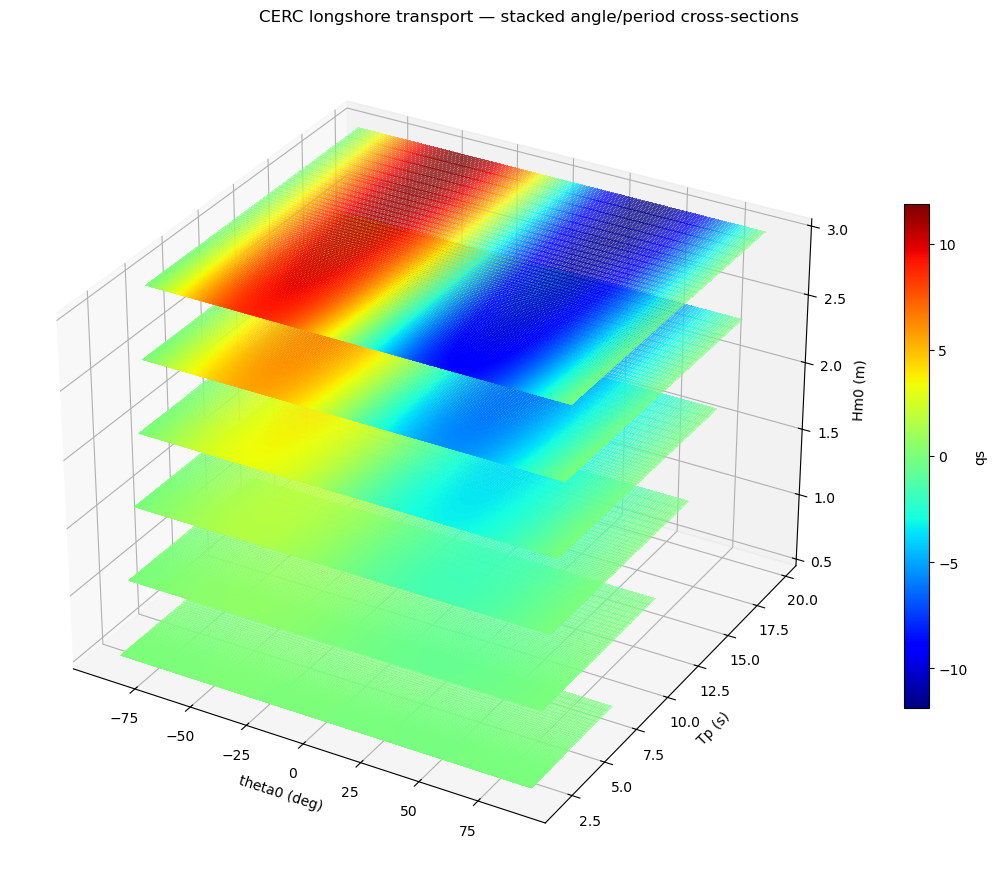

In [13]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

for hm0, tp_da, qs in zip(hm0_slices, tp_slices, qs_slices):
    z_plane = np.full_like(ang_grid, hm0)  
    facecolors = cmap(norm(qs))
    ax.plot_surface(
        ang_grid, tp_da, z_plane,
        facecolors=facecolors,
        rstride=1, cstride=1,
        shade=False, antialiased=False,
        linewidth=0,
        alpha=0.5
    )

ax.set_xlabel("theta0 (deg)")
ax.set_ylabel("Tp (s)")
ax.set_zlabel("Hm0 (m)")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, label="qs")
plt.suptitle("CERC longshore transport — stacked angle/period cross-sections")
plt.tight_layout()
plt.show()

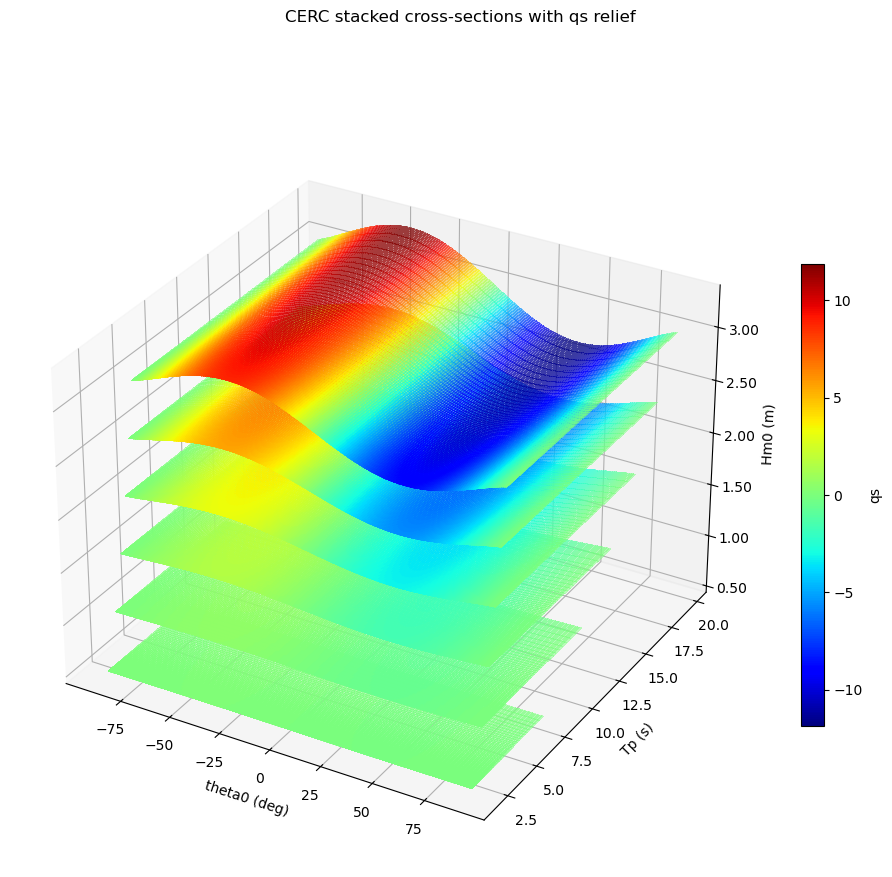

In [14]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

stack_spacing = 3.0 * vmax   
exaggeration = 2.0

for i, (hm0, tp_da, qs) in enumerate(zip(hm0_slices, tp_slices, qs_slices)):
    z_offset = i * stack_spacing              
    z_surface = z_offset + exaggeration*qs     
    facecolors = cmap(norm(qs))                

    ax.plot_surface(
        ang_grid, tp_da, z_surface,
        facecolors=facecolors,
        rstride=1, cstride=1,
        shade=False, antialiased=False,
        linewidth=0,
        alpha=0.5,
    )

ax.set_xlabel("theta0 (deg)")
ax.set_ylabel("Tp (s)")
ax.set_zlabel("Hm0 (m)")

ax.set_zticks([i * stack_spacing for i in range(len(hm0_slices))])
ax.set_zticklabels([f"{hm0:.2f}" for hm0 in hm0_slices])

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, label="qs")
plt.suptitle("CERC stacked cross-sections with qs relief")
plt.show()

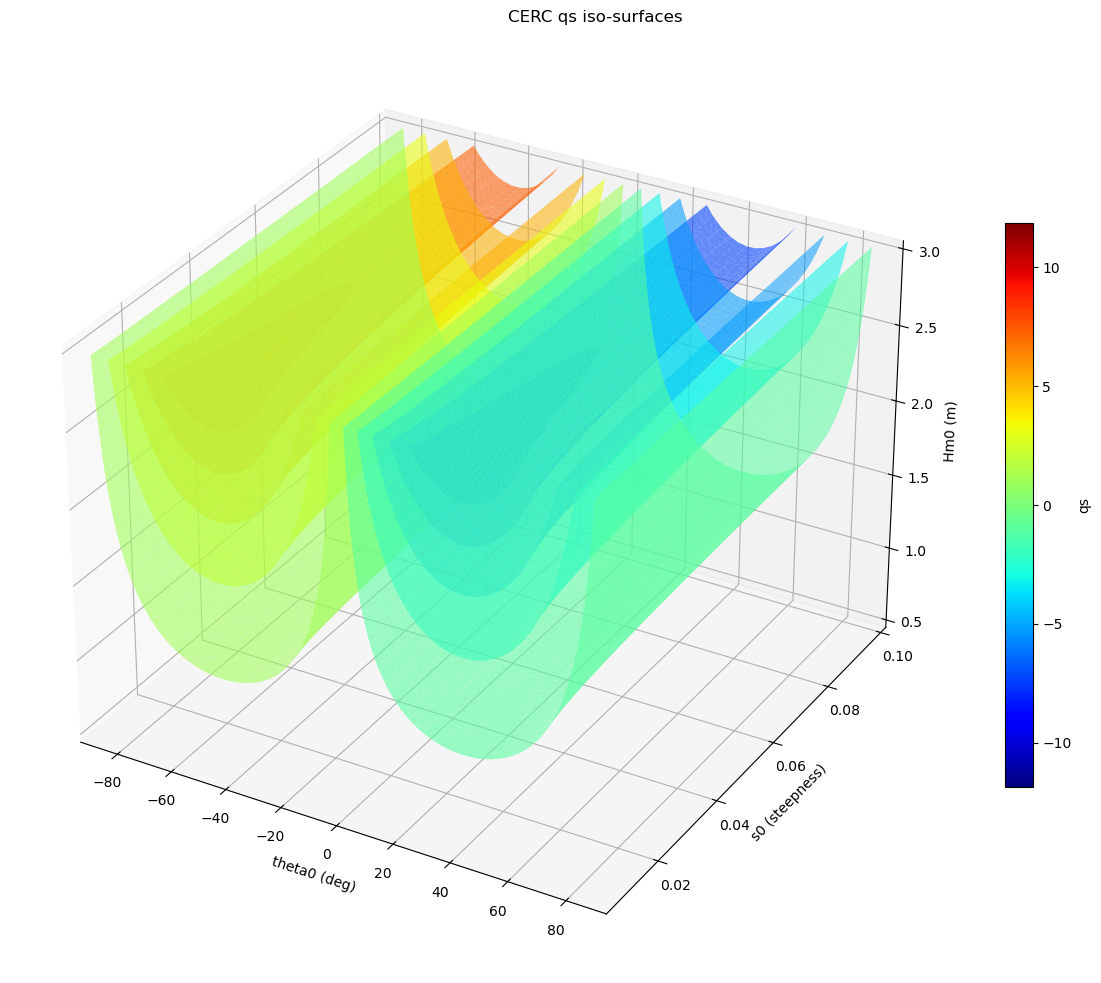

In [5]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure

n_ang_3d, n_s0_3d, n_hm0_3d = 60, 60, 60
ang_values_3d = np.linspace(ang_min, ang_max, n_ang_3d)
s0_values_3d = np.linspace(s0_min, s0_max, n_s0_3d)
hm0_values_3d = np.linspace(hm0_min, hm0_max, n_hm0_3d)
ang_vol, s0_vol, hm0_vol = np.meshgrid(ang_values_3d, s0_values_3d, hm0_values_3d, indexing="ij")
tp_vol = np.sqrt(hm0_vol / (1.56 * s0_vol))
angle_term_vol = np.radians(ang_vol)
cos_term = np.cos(angle_term_vol)
sin_term = np.sin(angle_term_vol)
qs_vol = -k * (tp_vol ** 0.2) * (hm0_vol ** 2.4) * (cos_term ** 1.2) * sin_term

qs_levels = np.linspace(qs_vol.min() * 0.8, qs_vol.max() * 0.8, 10)

neg_levels = sorted(qs_levels[qs_levels < 0])                 
pos_levels = sorted(qs_levels[qs_levels > 0], reverse=True)    
draw_order = list(neg_levels) + list(pos_levels)

vmax_3d = np.abs(qs_vol).max()
norm_3d = Normalize(-vmax_3d, vmax_3d)
cmap = plt.cm.jet

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

spacing = (
    ang_values_3d[1] - ang_values_3d[0],
    s0_values_3d[1] - s0_values_3d[0],
    hm0_values_3d[1] - hm0_values_3d[0],
)

for level in draw_order:
    verts, faces, _, _ = measure.marching_cubes(qs_vol, level=level, spacing=spacing)
    verts[:, 0] += ang_min
    verts[:, 1] += s0_min
    verts[:, 2] += hm0_min

    color = cmap(norm_3d(level))
    mesh = Poly3DCollection(verts[faces], alpha=0.6, facecolor=color, edgecolor="none")
    ax.add_collection3d(mesh)

ax.set_xlabel("theta0 (deg)")
ax.set_ylabel("s0 (steepness)")
ax.set_zlabel("Hm0 (m)")
ax.set_xlim(ang_min, ang_max)
ax.set_ylim(s0_min, s0_max)
ax.set_zlim(hm0_min, hm0_max)

sm = plt.cm.ScalarMappable(norm=norm_3d, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, label="qs")
plt.suptitle("CERC qs iso-surfaces")
plt.tight_layout()
plt.show()

In [9]:
import plotly.graph_objects as go

fig = go.Figure()

n_levels = 20
neg_levels = np.linspace(-1e-3, qs_vol.min() * 0.8, n_levels // 2)   
pos_levels = np.linspace(1e-3, qs_vol.max() * 0.8, n_levels // 2)    
all_levels = np.concatenate([pos_levels, neg_levels])

for level in all_levels:
    frac = np.abs(level) / vmax_3d
    opacity = float(0.1 + 0.5 * frac)

    fig.add_trace(go.Isosurface(
        x=ang_vol.flatten(),
        y=s0_vol.flatten(),
        z=hm0_vol.flatten(),
        value=qs_vol.flatten(),
        isomin=float(level),
        isomax=float(level),
        surface_count=1,
        colorscale="jet",
        reversescale=True,
        cmin=-vmax_3d, cmax=vmax_3d,
        cmid=0,
        caps=dict(x_show=False, y_show=False, z_show=False),
        opacity=opacity,
        showscale=bool(level == all_levels[-1]),
    ))

fig.update_layout(
    scene=dict(
        xaxis_title="theta0 (deg)",
        yaxis_title="s0 (steepness)",
        zaxis_title="Hm0 (m)",
    ),
    title="CERC transport — qs iso-surfaces",
    width=900, height=800,
)
fig.write_image("qs_isosurfaces.png", width=1200, height=1000, scale=2)